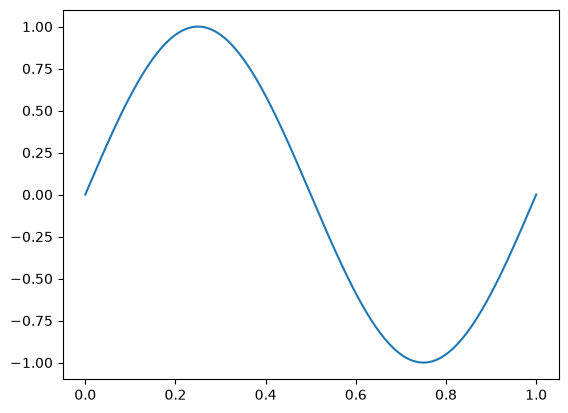

In [26]:
"""importation des bibliothèques/modules"""


import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio,display
from scipy.io import wavfile

""" Constantes utiles pour le TP"""
RATE = 44100
LA = 440
DO = 523.25

""" Questions : 
1) Pour échantilloner un son de 440Hz, il faut 44100 échantillons par seconde (le RATE)
2)  position = A*sin(2*np.pi*phi*t), avec A l'amplitude de la vibration 

3)

abscisses = np.linspace(0,1,RATE)  # on crée l'array du temps 
ordonnées = np.sin(2*np.pi*LA*abscisses) # on calcule les valeurs de notre signal sinusoïdal

plt.plot(abscisses, ordonnées, color='red') #tracé du graphe
plt.show()

display(Audio(ordonnées,rate=RATE)) # on transforme le graphe en fichier son 
"""
#4) 

t = np.linspace(0,1,RATE) #la liste de temps
def display_signal(signal, rate=RATE, title="Signal", width=1) : #signal à échantilloner/fréquance d'échantillonage
    abs = np.linspace(0,1,rate)
    plt.plot(abs, signal)
    plt.show()
    display(Audio(signal,rate=RATE))

display_signal(np.sin(2*np.pi*t)) # on teste la fonction avec notre sinus sur l'intervalle de temps choisi


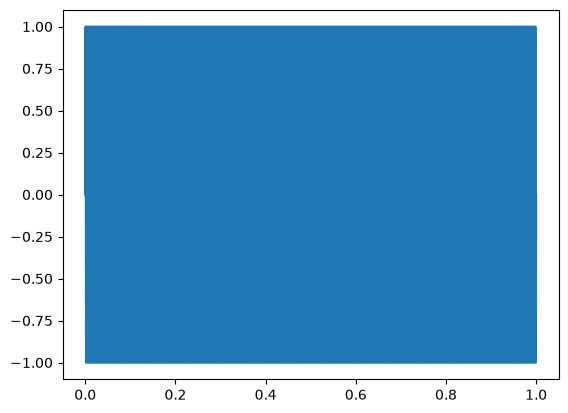

In [17]:
#2.2
RATE =44100

def sine(freq, rate=RATE,duration=1,amplitude=1) : #on met des valeurs défauts pour empêcher une erreur d'arguments
    abs = np.linspace(0,1,rate)
    ord = np.sin(2*np.pi*freq*abs)
    plt.plot(abs, ord)
    plt.show()
    display(Audio(ord,rate=RATE) )

sine(440)

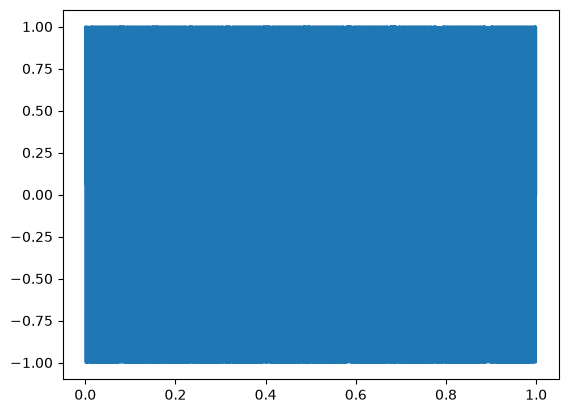

In [ ]:
#2.3 ; glissando

RATE = 44100
def sine_linear(freq1,freq2,duration=1,amplitude=1) :
    varfreq =np.linspace(freq1,freq2,RATE)
    abs = np.linspace(0,1,RATE)
    phases = (1/RATE)*2*np.pi*np.cumsum(varfreq)
    ord = np.sin(2*np.pi*varfreq*abs+ phases ) # on ajoute la phase pour ne pas avoir de décalage 
    plt.plot(abs, ord)
    plt.show()
    display(Audio(ord,rate=RATE) )

sine_linear(440,523) # on teste


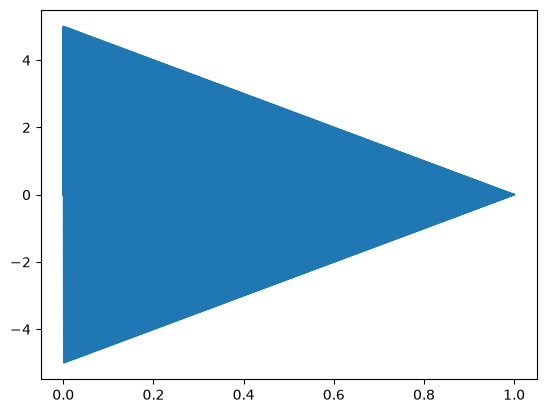

In [19]:
#3 Gestion du volume et de la dynamique
# 1)Pour moduler l'amplitude de la sinusoïde, on crée un tableau d'amplitude qui va varier avec la liste de temps

RATE =44100

def crescendo_sine(freq, amplitude=1, duration=1, increase =True) :
    if increase :
        ampl = np.linspace(0,1,RATE)
    else :
        ampl = np.linspace(1,0,RATE)
    abs = np.linspace(0,1,RATE)
    ord = amplitude*ampl*np.sin(2*np.pi*freq*abs)
    plt.plot(abs, ord)
    plt.show()
    display(Audio(ord,rate=RATE) )
    
crescendo_sine(440,5,1,False)


In [20]:
#4 CONCATENATION DE SONS
RATE=44100

def concatenation(freq1,freq2,duration1=1,duration2 =1) :
    temps1=np.linspace(0,duration1,RATE)
    temps2=np.linspace(0,duration2,RATE)
    son1 = np.sin(2*np.pi*freq1*temps1)
    son2 = np.sin(2*np.pi*freq2*temps2)
    son = np.concatenate((son1,son2))
    display(Audio(son,rate=RATE))

concatenation(440,880) #test

In [21]:
#5 Format de données audio
#5.3

def float_to_int16(as_float) :
    int.astype(np.int16) # on transforme les valeurs du tableau en les entiers codés sur 16bits




In [ ]:
#6 Les fréquences des notes de game
alpha = 2**(1/12) #le rapport de demi-ton
#1) 
ratios = [ alpha*i for i in range(13) ]

#2)


def freq_from_name(name) :
    note ={'do' :1 , 'do#' : 2, 'ré' : 3, 'ré#' :4, 'mi':5, 'fa' :6,'fa#':7, 'sol':8, 'sol#':9, 'la':10,'la#':11,'si':12}
    return 440*alpha**(note[name] -note['la']) #on doit décaler la fréquance de référence jusqu'au 'la'



freq_from_name('la') == 440. #test de la fonction




True

In [29]:
#7) 
# Pour réaliser un accord, nous allons sommer les vibrations sonores

RATE = 44100


def accords(freq1,freq2 , duration =1):
    temps = np.linspace(0,duration,RATE)
    son1= np.sin(2*np.pi*freq1*temps)
    son2= np.sin(2*np.pi*freq2*temps)
    accord = son1+ son2 #on crée notre accord ; superposition des sons
    display(Audio(accord, rate = RATE))

accords(440,700,2)





In [36]:
# 8 )
from scipy.io import wavfile
RATE =44100


""" On enregistre le fichier """

sample = wavfile.write( 'pin-pon-fa-sol.wav' , RATE , np.int16 ) # on réutilise la cellule de code 8) pour produire le son



AttributeError: 'getset_descriptor' object has no attribute 'kind'

44100 Hz
405891
9.203877551020408 s


<function matplotlib.pyplot.show(close=None, block=None)>

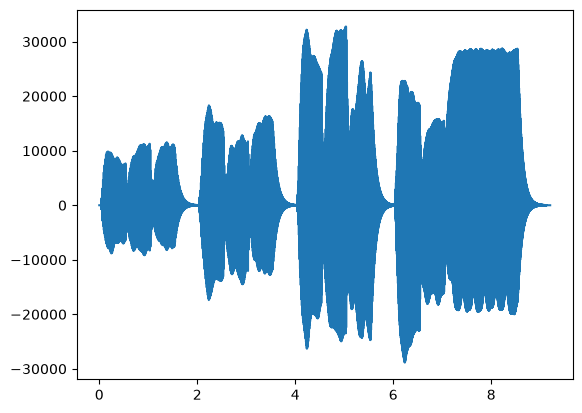

In [ ]:
# 9 ) 

RATE , data = wavfile.read('/Users/nathansagnes/cours-info/TP_Python_numerique/TP_SON/media/sounds-cello.wav')

display(Audio(data, rate = RATE)) #on lit le fichier

print(RATE,'Hz') # fréquence d'échantillonage 

print( len(data))  # nombre total d'échantillons

print( len(data)/RATE , 's') # durée de l'échantillon

temps = np.linspace(0, len(data)/RATE , len(data) ) # on crée une échelle de temps de même dimension que le signal
plt.plot(temps , data)
plt.show


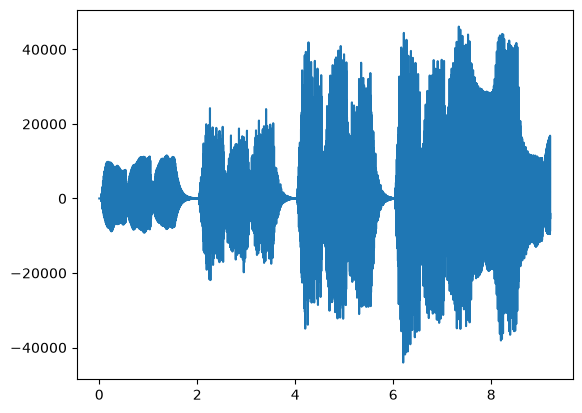

In [ ]:
#10 ) 
RATE = 44100
temps = np.linspace(0, len(data)/RATE , len(data) )
# Paramètres pour l'écho
delay = 2  # en secondes
main_ratio, delayed_ratio = 0.7, 0.3

offset = delay*RATE

base = np.zeros(len(data))
data_echo = data[: len(data)-offset]
base[offset:] = data_echo


signal_echo1 = data+ main_ratio*base
display(Audio(signal_echo1, rate = RATE)) #on teste le signal d'écho
plt.plot(temps,signal_echo1) #on affiche l'echo
plt.show()


Question 11.12 quest de as.type : il faut changer le type des éléments en int.32 pour qu'on puisse faire des calculs, puis retourner sur int.16